In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs

In [10]:
#K Mean Algorithm

In [11]:
#Node Mathematics 
#Let x=x1,x2,x3.....xn
#Uj be the centroid of cluster j
#Cj be the set of points in cluster j


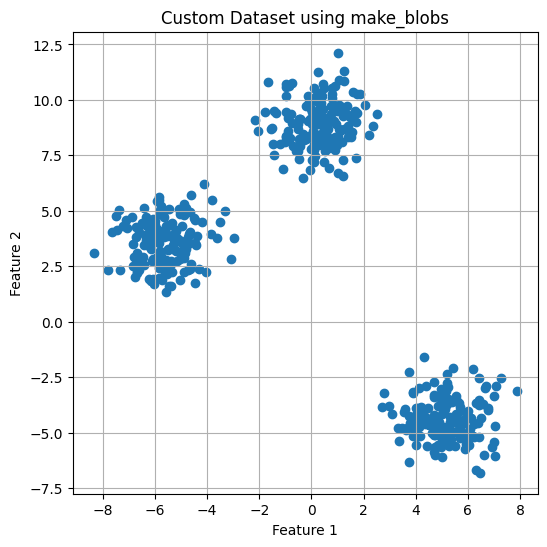

In [15]:
#Create Custum data set with make_blob and plot it 


X, y = make_blobs(n_samples=500, n_features=2, centers=3, random_state=23)

plt.figure(figsize=(6,6))
plt.grid(True)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Custom Dataset using make_blobs")
plt.show()


In [18]:
#initilizing random centroids
k = 3
clusters = {}

np.random.seed(23)

for idx in range(k):
    center = np.random.uniform(-1, 1, size=X.shape[1])
    clusters[idx] = {
        'center': center,
        'points': []
    }

clusters


{0: {'center': array([0.03459577, 0.89392521]), 'points': []},
 1: {'center': array([ 0.53091952, -0.43520831]), 'points': []},
 2: {'center': array([-0.55790927,  0.37244417]), 'points': []}}

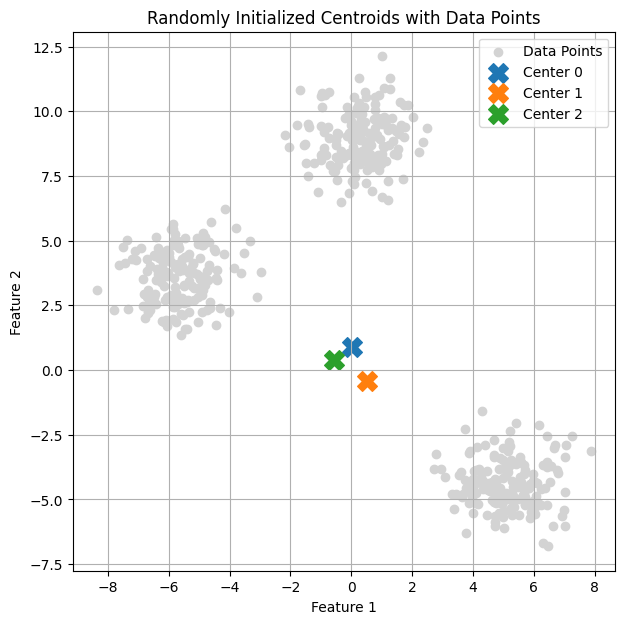

In [20]:
#PLOTTING RANDOM INITIASE CENTER WITH DATA POINTS
plt.figure(figsize=(7,7))
plt.grid(True)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c='lightgray', label='Data Points')

# Plot random initial centroids
for idx, cluster in clusters.items():
    center = cluster['center']
    plt.scatter(center[0], center[1], 
                marker='X', s=200, label=f'Center {idx}')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Randomly Initialized Centroids with Data Points")
plt.legend()
plt.show()









In [21]:
#dEFINING EUCLIDEAN DISTANCE
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [22]:
#CREATING FUNCTION ASSIGN AND UPDATE THE CLUSTER
def assign_clusters(X, clusters):
    # Clear previous points
    for idx in clusters:
        clusters[idx]['points'] = []

    # Assign each data point to nearest centroid
    for x in X:
        distances = []
        for idx, cluster in clusters.items():
            dist = euclidean_distance(x, cluster['center'])
            distances.append((idx, dist))
        
        # Find nearest cluster
        closest_cluster = min(distances, key=lambda t: t[1])[0]
        clusters[closest_cluster]['points'].append(x)

    return clusters


In [23]:
#CREATING FUNCTION TO PREDICT THE CLUSTER FOR THE DATAPOINTS
def predict_clusters(X, clusters):
    predictions = []

    for x in X:
        distances = []
        for idx, cluster in clusters.items():
            dist = euclidean_distance(x, cluster['center'])
            distances.append(dist)
        
        # Assign to nearest cluster
        predictions.append(np.argmin(distances))

    return np.array(predictions)


In [24]:
#ASSIGN UPDATE AND PREDICT THE CLUSTER CENTER
def assign_clusters(X, clusters):
    # Clear old points
    for idx in clusters:
        clusters[idx]['points'] = []

    # Assign each point
    for x in X:
        distances = []
        for idx, cluster in clusters.items():
            distances.append(euclidean_distance(x, cluster['center']))
        
        nearest_cluster = np.argmin(distances)
        clusters[nearest_cluster]['points'].append(x)

    return clusters


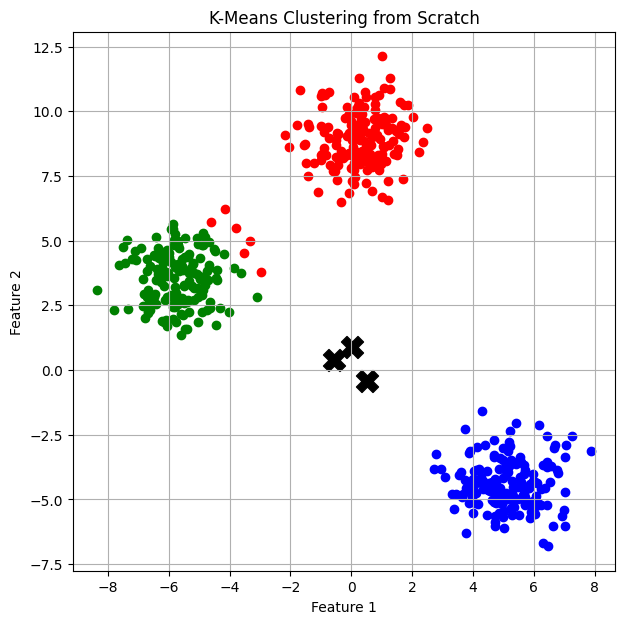

In [27]:
#PLOTTING DATA POINTS WITH THEIR PREDICTED CLUSTER CENTERS
y_pred = predict_clusters(X, clusters)

colors = ['red', 'blue', 'green']

plt.figure(figsize=(7,7))
plt.grid(True)

for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], color=colors[y_pred[i]])

# Plot cluster centers
for idx, cluster in clusters.items():
    plt.scatter(cluster['center'][0], cluster['center'][1],
                color='black', marker='X', s=250)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering from Scratch")
plt.show()




In [28]:
#FIND ELBOW POINT WHERE THE CURVE BENDS THATS THE OPTIMAL K , SAMPLE DATA ELBOW METHOD AND PLOT
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=500, n_features=2, centers=4, random_state=42)


In [29]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))


def init_centroids(X, k):
    np.random.seed(42)
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


def assign_labels(X, centroids):
    labels = []
    for x in X:
        distances = [euclidean_distance(x, c) for c in centroids]
        labels.append(np.argmin(distances))
    return np.array(labels)


def update_centroids(X, labels, k):
    centroids = []
    for i in range(k):
        centroids.append(X[labels == i].mean(axis=0))
    return np.array(centroids)


In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    centroids = init_centroids(X, k)

    # Run K-Means for fixed iterations
    for _ in range(10):
        labels = assign_labels(X, centroids)
        centroids = update_centroids(X, labels, k)

    # Calculate WCSS
    total_wcss = 0
    for i in range(k):
        cluster_points = X[labels == i]
        total_wcss += np.sum((cluster_points - centroids[i]) ** 2)

    wcss.append(total_wcss)
